In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import torch
import torch.nn as nn
import numpy as np
import shap

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Neural Network

## Data preprocessing

In [2]:
data = pd.read_csv("dataset_refining/german_credit_data_with_risk.csv")
data = data.fillna(0)
data["credit_risk"] = data["credit_risk"].map({1: 1, 2: 0})

pd.set_option('future.no_silent_downcasting', True)
data["Checking account"] = data["Checking account"].replace({"little": 1, "moderate": 2, "rich": 3}).astype(int)
data["Saving accounts"]  = data["Saving accounts"].replace({"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}).astype(int)
data["Housing"]          = data["Housing"].replace({"free": 0, "rent": 1, "own": 2}).astype(int)

purpose_map = {
    "radio/TV": 0,
    "car": 0,
    "vacation/others": 0,
    "furniture/equipment": 1,
    "repairs": 1,
    "domestic appliances": 1,
    "education": 2,
    "business": 2
}

data["Purpose"] = data["Purpose"].map(purpose_map).astype(int)

X = data.drop(columns=["credit_risk"])
y = data["credit_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Column groups ---
numeric_cols = ["Age", "Credit amount", "Duration"]

# Ordinal: order matters, so we keep ordinal encoding
ordinal_cols   = ["Checking account", "Saving accounts", "Housing", "Purpose", "Job"]

# --- Preprocessor ---
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols + ordinal_cols),
], remainder="drop")

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

feature_names_out  = numeric_cols + ordinal_cols

print(f"Train shape: {X_train_proc.shape}")
print(f"Feature names: {feature_names_out}")

Train shape: (800, 8)
Feature names: ['Age', 'Credit amount', 'Duration', 'Checking account', 'Saving accounts', 'Housing', 'Purpose', 'Job']


## Training

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

In [4]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# Convert to tensors
X_train_t = torch.tensor(X_train_proc, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_proc,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

model     = MLP(input_dim=X_train_t.shape[1])
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

history = {"train_loss": [], "test_loss": [],
           "train_acc":  [], "test_acc":  [],
           "train_f1":   [], "test_f1":   [],
           "train_auc":  [], "test_auc":  []}

epochs = 200
for epoch in range(epochs):
    # --- Train ---
    model.train()
    outputs = model(X_train_t)
    loss    = criterion(outputs, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # --- Eval (no gradients needed) ---
    model.eval()
    with torch.no_grad():
        train_proba = model(X_train_t).numpy().flatten()
        test_proba  = model(X_test_t).numpy().flatten()

    train_pred = (train_proba >= 0.5).astype(int)
    test_pred  = (test_proba  >= 0.5).astype(int)
    y_tr = y_train.values
    y_te = y_test.values

    train_loss = criterion(torch.tensor(train_proba).unsqueeze(1), y_train_t).item()
    test_loss  = criterion(torch.tensor(test_proba).unsqueeze(1),  y_test_t).item()

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(accuracy_score(y_tr, train_pred))
    history["test_acc"].append(accuracy_score(y_te, test_pred))
    history["train_auc"].append(roc_auc_score(y_tr, train_proba))
    history["test_auc"].append(roc_auc_score(y_te, test_proba))
    history["train_f1"].append(f1_score(y_tr, train_pred))
    history["test_f1"].append(f1_score(y_te, test_pred))

    if epoch % 5 == 0:
        print(f"Epoch {epoch:>3} | "
              f"Loss: {train_loss:.4f}/{test_loss:.4f} | "
              f"Acc: {history['train_acc'][-1]:.4f}/{history['test_acc'][-1]:.4f} | "
              f"F1: {history['train_f1'][-1]:.4f}/{history['test_f1'][-1]:.4f} | "
              f"AUC: {history['train_auc'][-1]:.4f}/{history['test_auc'][-1]:.4f}")

Epoch   0 | Loss: 0.7321/0.7344 | Acc: 0.3100/0.3300 | F1: 0.0383/0.0822 | AUC: 0.6202/0.6436
Epoch   5 | Loss: 0.7004/0.7004 | Acc: 0.4562/0.4450 | F1: 0.4373/0.4188 | AUC: 0.6068/0.6339
Epoch  10 | Loss: 0.6774/0.6767 | Acc: 0.6062/0.6000 | F1: 0.6909/0.6875 | AUC: 0.5951/0.5964
Epoch  15 | Loss: 0.6595/0.6587 | Acc: 0.6663/0.6800 | F1: 0.7766/0.7867 | AUC: 0.5907/0.5825
Epoch  20 | Loss: 0.6433/0.6429 | Acc: 0.6975/0.6700 | F1: 0.8118/0.7925 | AUC: 0.5959/0.5835
Epoch  25 | Loss: 0.6280/0.6281 | Acc: 0.6975/0.6550 | F1: 0.8178/0.7903 | AUC: 0.6086/0.5973
Epoch  30 | Loss: 0.6131/0.6142 | Acc: 0.7050/0.6750 | F1: 0.8252/0.8060 | AUC: 0.6271/0.6183
Epoch  35 | Loss: 0.5988/0.6011 | Acc: 0.7063/0.6900 | F1: 0.8261/0.8166 | AUC: 0.6505/0.6451
Epoch  40 | Loss: 0.5854/0.5889 | Acc: 0.7075/0.6900 | F1: 0.8269/0.8166 | AUC: 0.6741/0.6676
Epoch  45 | Loss: 0.5730/0.5781 | Acc: 0.7100/0.6850 | F1: 0.8276/0.8131 | AUC: 0.6941/0.6810
Epoch  50 | Loss: 0.5620/0.5693 | Acc: 0.7063/0.6900 | F1: 0

## Global Results

In [6]:
print("=" * 40)
print(f"  Accuracy : {history["test_acc"][-1]:.4f}")
print(f"  F1 Score : {history["test_f1"][-1]:.4f}")
print(f"  AUC      : {history["test_auc"][-1]:.4f}")
print("=" * 40)

  Accuracy : 0.7550
  F1 Score : 0.8316
  AUC      : 0.7650


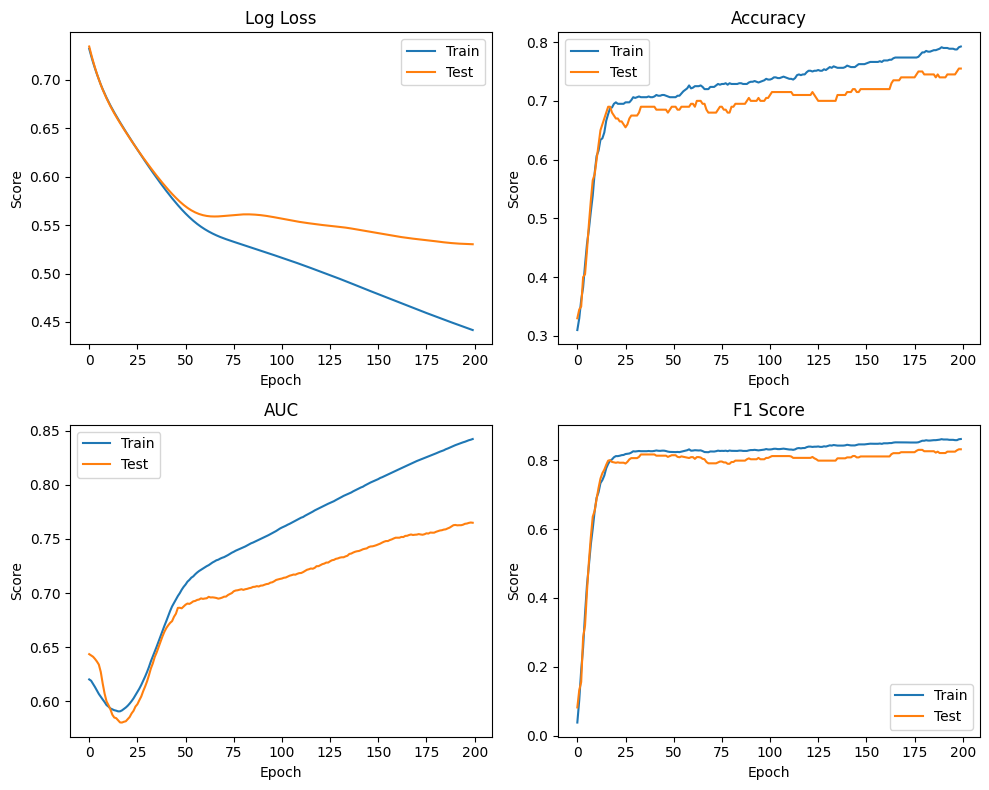

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# --- Loss ---
axs[0, 0].plot(history["train_loss"], label="Train")
axs[0, 0].plot(history["test_loss"],  label="Test")
axs[0, 0].set_title("Log Loss")
axs[0, 0].legend()

# --- Accuracy ---
axs[0, 1].plot(history["train_acc"], label="Train")
axs[0, 1].plot(history["test_acc"],  label="Test")
axs[0, 1].set_title("Accuracy")
axs[0, 1].legend()

# --- AUC ---
axs[1, 0].plot(history["train_auc"], label="Train")
axs[1, 0].plot(history["test_auc"],  label="Test")
axs[1, 0].set_title("AUC")
axs[1, 0].legend()

# --- F1 ---
axs[1, 1].plot(history["train_f1"], label="Train")
axs[1, 1].plot(history["test_f1"],  label="Test")
axs[1, 1].set_title("F1 Score")
axs[1, 1].legend()

for ax in axs.flat:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

The model converges within 200 epochs, though mild overfitting is visible in the later epochs - train metrics continue improving slightly while test metrics plateau. The curves suggest the model is close to its capacity limit for this dataset; further epochs or a more complex architecture would likely increase overfitting without meaningful gains on unseen data.

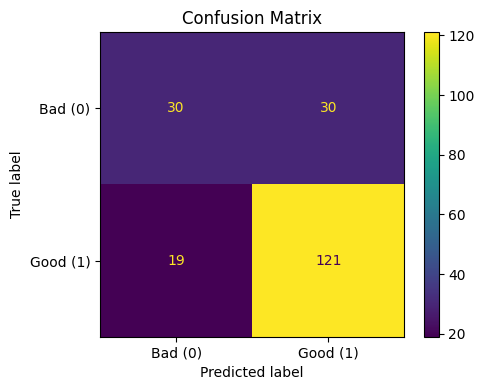

In [8]:
model.eval()
with torch.no_grad():
    test_proba = model(X_test_t).numpy().flatten()

y_pred  = (test_proba >= 0.5).astype(int)
y_proba = test_proba

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred, display_labels=["Bad (0)", "Good (1)"], ax=ax
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly predicts most 'Good' cases (121/140) but struggles with 'Bad' cases (30/60), misclassifying 30 bad credits as good. The model remains biased toward the majority class, which is a direct consequence of the class imbalance in the dataset.

In [9]:
explainer = shap.GradientExplainer(model, X_train_t)
shap_values = explainer.shap_values(X_test_t)
shap_values_2d = shap_values[0].squeeze(-1) if isinstance(shap_values, list) else shap_values.squeeze(-1)

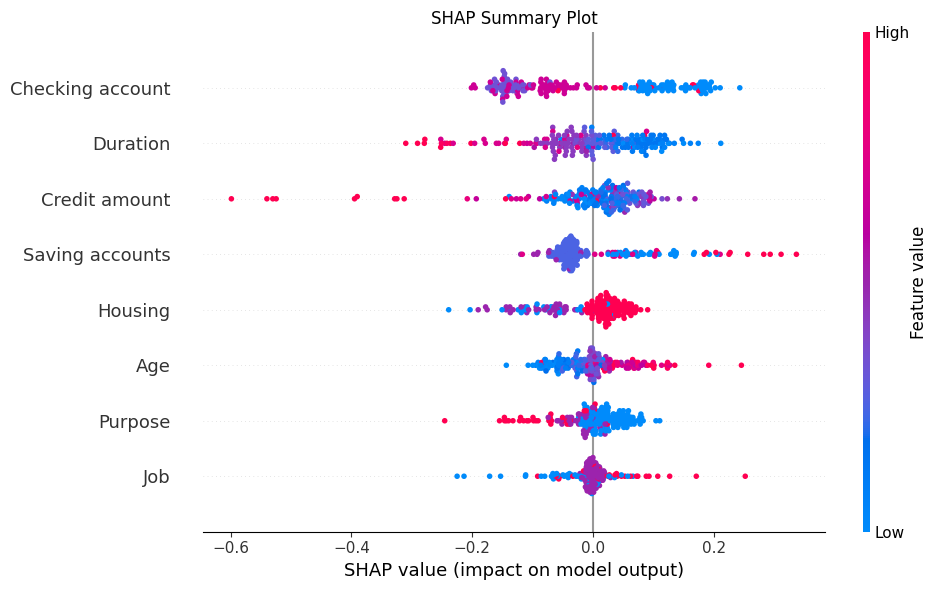

In [10]:
plt.figure()
shap.summary_plot(shap_values_2d, X_test_t.numpy(), feature_names=feature_names_out, plot_size=(10, 6), show=False, rng=42)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

- **Checking account** - same as in XGBoost, a value of `0` (no recorded checking account) contributes positively to good credit risk-likely reflecting individuals who maintain accounts in other banks or have alternative financial arrangements. Small or moderate balances are associated with higher risk, while high balances slightly increase predicted safety.
- **Duration** - There is a clear trend with longer duraction leading to higher risk (low shap values), the classes are pretty well separated (not perfect though).
- **Credit amount** - values are not so well separated, but high values have a very clear negative impact (the most significant across all criterions) while moderately low values a positive impact. Low values are around 0 likely because for someone with low credit, it is more likely that this low credit is all he can get.
- **Saving Accounts** - here `0` reffers to no saving account and it correlates positively with good risk maybe because those people invest their money outside banks and it serves them better, on the other hand people with rich saving accounts also score well which is obvious. Most people have little money on saving accounts and the model penalizes it slightly
- **Housing** - Owners get a small positive value, and non-owners get a penalty. 
- **Age** - Generally higher = better, with experience people generally advance their careers, build their own capital and have greater stability in life
- **Purpose** - Here high and middle values reffer to ambitious and necessary purposes like school are repairs, it may be that people who take these loans are in a bad position in their life which correlates with bad risk, people who take their loans recklessly for cars and holidays are often in a more stable position
- **Job** - Generally better job is better (lower) credit risk

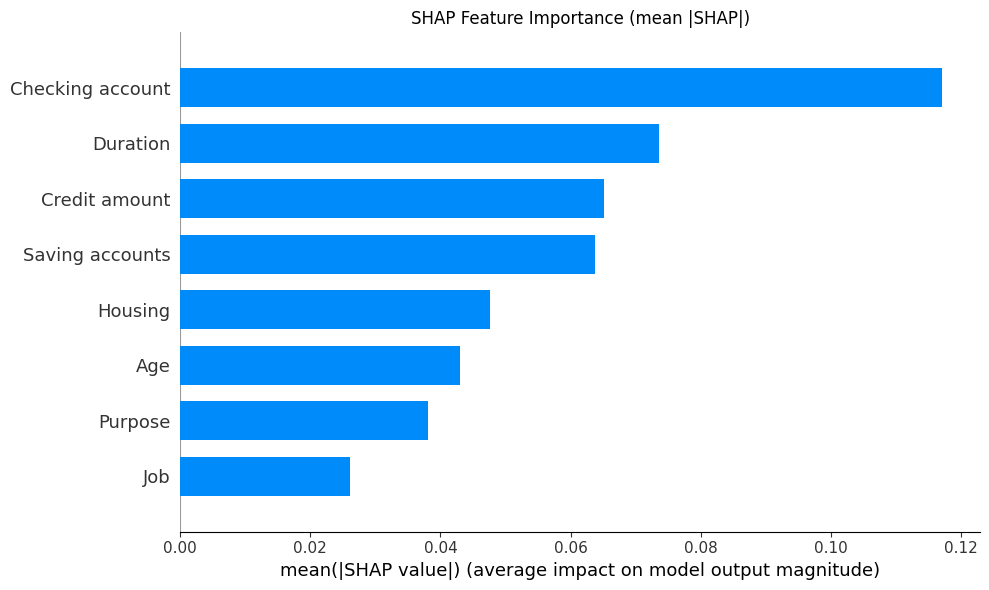

In [11]:
plt.figure()
shap.summary_plot(shap_values_2d, X_test_t.numpy(), feature_names=feature_names_out, plot_size=(10, 6), plot_type="bar", show=False, rng=42)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

The SHAP feature importance shows that `Checking account` is by far the most influential feature, significantly exceeding all others. It is followed by `Duration`, `Credit amount` and `Saving accounts`, indicating that the model relies primarily on financial attributes. `Housing`, `Age` and `Purpose` have moderate importance, and lastly`Job` contributes the least to the model's predictions.

## Sample Analysis

In [12]:
def plot_shap_waterfall_nn(explainer, sample_proc, feature_names, X_test_t):
    tensor = torch.tensor(sample_proc, dtype=torch.float32)
    sv = explainer.shap_values(tensor)
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.array(sv).squeeze()  # force to 1D (n_features,)

    model.eval()
    with torch.no_grad():
        base = model(X_test_t).squeeze().mean().item()

    shap.plots._waterfall.waterfall_legacy(
        base, sv,
        feature_names=feature_names,
        max_display=10
    )
    prob = predict_proba_nn(model, sample_proc)
    cls  = int(float(prob) > 0.5)
    print(f"Predicted probability (class 1): {float(prob):.4f}  →  class {cls}")

In [13]:
def minimal_flip(model, X_test, idx, feature, max_steps=100, step_fraction=0.01, direction=1):
    model.eval()
    
    def predict_class(df_row):
        tensor = torch.tensor(df_row.values, dtype=torch.float32)
        with torch.no_grad():
            output = model(tensor)
            return int((output.squeeze() > 0.5).item())
    
    X_sample = X_test.iloc[[idx]].copy()
    original_class = predict_class(X_sample)
    
    if X_sample[feature].dtype.kind in 'iuf':
        step = step_fraction * (X_test[feature].max() - X_test[feature].min())
        if X_sample[feature].dtype.kind == 'i':
            step = max(1, round(step))
    else:
        step = 1
    
    sample_cf = X_sample.copy()
    for i in range(1, max_steps + 1):
        if X_sample[feature].dtype.kind in 'iuf':
            sample_cf[feature] += step * direction
        else:
            sample_cf[feature] = int(sample_cf[feature] + step * direction)
        
        new_class = predict_class(sample_cf)
        if new_class != original_class:
            return {
                'original_class': original_class,
                'flipped_class': new_class,
                'feature': feature,
                'total_change': step * i,
                'steps': i,
                'sample_cf': sample_cf
            }
    
    return {
        'original_class': original_class,
        'flipped_class': original_class,
        'feature': feature,
        'total_change': 0,
        'steps': 0,
        'sample_cf': sample_cf
    }

In [14]:
model.eval()

explainer  = shap.GradientExplainer(model, X_train_t)

X_test_df  = pd.DataFrame(X_test_proc,  columns=feature_names_out)
X_train_df = pd.DataFrame(X_train_proc, columns=feature_names_out)

# precompute SHAP values for the whole test set (needed for groupby analysis)
shap_values_nn = explainer.shap_values(X_test_t).squeeze()  # shape: (n_samples, n_features)

### Sample selection

In [15]:
def predict_proba_nn(model, X):
    # accepts numpy array or DataFrame
    if isinstance(X, np.ndarray):
        tensor = torch.tensor(X, dtype=torch.float32)
    else:
        tensor = torch.tensor(X.values.astype(float), dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        output = model(tensor).squeeze()
    return output.numpy()

def predict_nn(model, X):
    proba = predict_proba_nn(model, X)
    return (proba > 0.5).astype(int)

probas = predict_proba_nn(model, X_test_proc)
preds  = predict_nn(model, X_test_proc)

idx_1 = 12
idx_2 = 71
idx_3 = 131
print(f"Probability {idx_1}:", probas[idx_1])
print(f"Probability {idx_2}:", probas[idx_2])
print(f"Probability {idx_3}:", probas[idx_3])

Probability 12: 0.5781058
Probability 71: 0.5063002
Probability 131: 0.53907317


### Sample 12

#### Analytical

In [16]:
idx = 12
sample_proc = X_test_proc[[idx]]
sample_df = X_test_df.iloc[[idx]].copy()

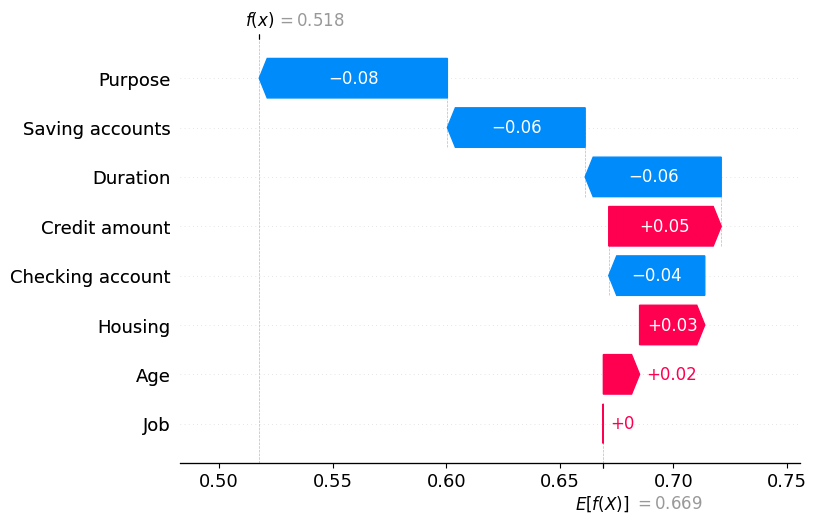

Predicted probability (class 1): 0.5781  →  class 1


In [17]:
plot_shap_waterfall_nn(explainer, sample_proc, feature_names_out, X_test_t)

In [18]:
display(sample_df)

,Age,Credit amount,Duration,Checking account,Saving accounts,Housing,Purpose,Job
12,0.053977,0.263304,0.508166,1.074861,-0.186225,0.570794,1.977903,0.146418


`Credit amount` - one of the more influential attributes is adding the most value right now, by reducing it I will be able to move the score down. Right now we are missing `0.5781` shap value.

In [19]:
feature_name = "Credit amount"
feature_idx  = feature_names_out.index(feature_name)
checking_shap = shap_values_nn[:, feature_idx]

grouped = X_test_df.copy()
grouped["shap_value"] = checking_shap

# bin into 10 equal-width buckets
grouped["bin"] = pd.cut(grouped[feature_name], bins=10)
avg_by_bin = grouped.groupby("bin", observed=False)["shap_value"].mean()

print(avg_by_bin)
print(
    f"Difference in avg SHAP between 3rd and 9th bin of '{feature_name}':",
    avg_by_bin.iloc[2] - avg_by_bin.iloc[8]
)

bin
(-1.034, -0.468]   -0.012496
(-0.468, 0.0927]    0.033935
(0.0927, 0.653]     0.063442
(0.653, 1.213]      0.043781
(1.213, 1.774]     -0.042644
(1.774, 2.334]     -0.061556
(2.334, 2.895]      0.004290
(2.895, 3.455]     -0.301799
(3.455, 4.015]     -0.562003
(4.015, 4.576]     -0.539459
Name: shap_value, dtype: float64
Difference in avg SHAP between 3rd and 9th bin of 'Credit amount': 0.6254453165312333


Looking at the avg SHAP values differences, I have to increase `Credit amount` by ~3.2

In [20]:
sample_df['Credit amount'] = 3.5

In [21]:
predict_proba_nn(model, sample_df)

array(0.084618, dtype=float32)

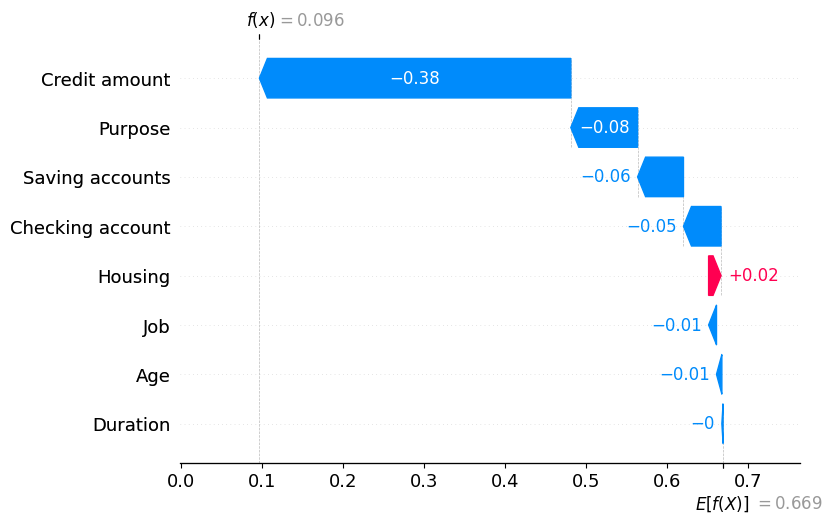

Predicted probability (class 1): 0.0846  →  class 0


In [23]:
feature_idx_num = feature_names_out.index("Checking account")
plot_shap_waterfall_nn(explainer, sample_df.to_numpy(), feature_names_out, X_test_t)

#### Sampling

In [24]:
res = minimal_flip(model, X_test_df, idx, feature='Credit amount', max_steps=100, step_fraction=0.01, direction=1)
res

{'original_class': 1,
 'flipped_class': 0,
 'feature': 'Credit amount',
 'total_change': np.float64(0.7284738089061445),
 'steps': 13,
 'sample_cf':          Age  Credit amount  Duration  Checking account  Saving accounts  \
 12  0.053977       0.991777  0.508166          1.074861        -0.186225   
 
      Housing   Purpose       Job  
 12  0.570794  1.977903  0.146418  }

In [25]:
res["sample_cf"]

,Age,Credit amount,Duration,Checking account,Saving accounts,Housing,Purpose,Job
12,0.053977,0.991777,0.508166,1.074861,-0.186225,0.570794,1.977903,0.146418


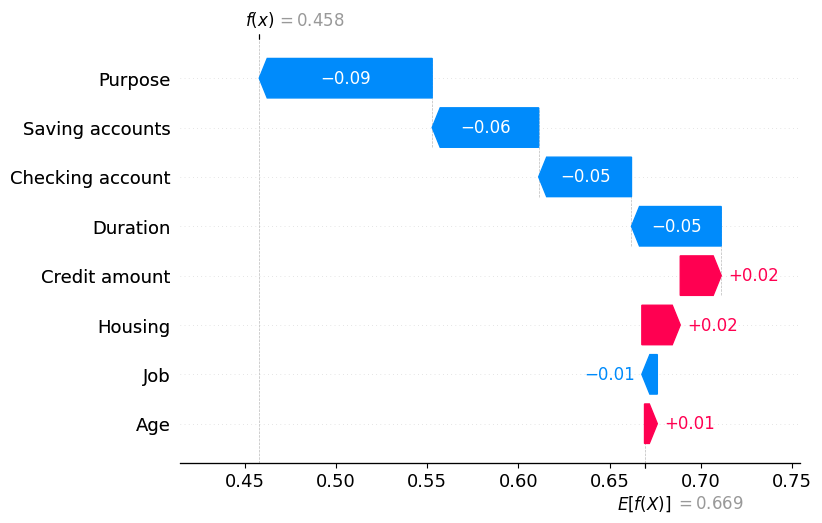

Predicted probability (class 1): 0.4942  →  class 0


In [26]:
plot_shap_waterfall_nn(explainer, res["sample_cf"].values, feature_names_out, X_test_t)

The analytical estimate **3.2** was based on average SHAP values across bins of the test set, which don't reflect the specific feature interactions for this individual sample. The sampling result **0.73** is more precise because it directly probes the model's decision boundary for this exact alternative. The discrepancy highlights a key limitation of using population-averaged SHAP values for individual counterfactual reasoning.

### Sample 71

#### Analytical

In [27]:
idx = 71
sample_proc = X_test_proc[[idx]]
sample_df = X_test_df.iloc[[idx]].copy()

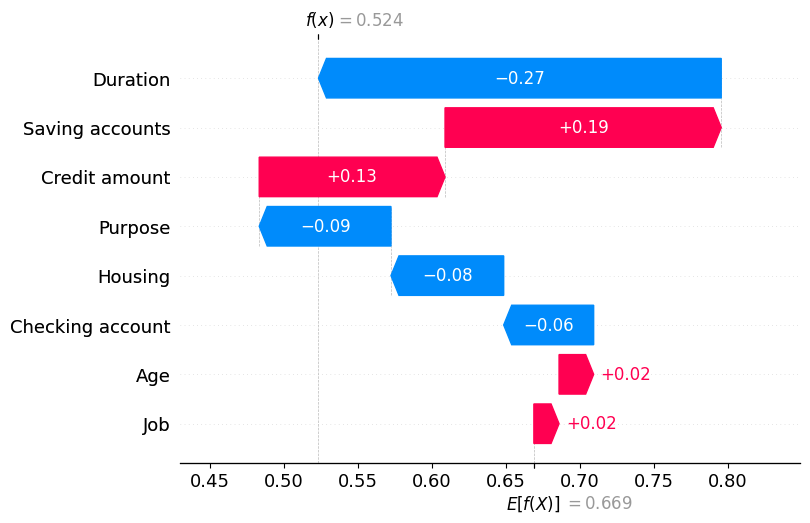

Predicted probability (class 1): 0.5063  →  class 1


In [28]:
plot_shap_waterfall_nn(explainer, sample_proc, feature_names_out, X_test_t)

In [29]:
display(sample_df)

,Age,Credit amount,Duration,Checking account,Saving accounts,Housing,Purpose,Job
71,0.229868,1.262123,2.237043,1.074861,-1.235378,-2.443298,1.977903,0.146418


`Duration` - one of the more influential attributes is taking away the most SHAP value right now, by reducing it I will be able to move the score down. Right now we have `0.5063` extra SHAP value to be disposed of.

In [30]:
feature_name = "Duration"
feature_idx  = feature_names_out.index(feature_name)

checking_shap = shap_values_nn[:, feature_idx]

grouped = X_test_df.copy()
grouped["shap_value"] = checking_shap
avg_by_value = grouped.groupby(feature_name)["shap_value"].mean()
print(avg_by_value)
print(
    f"Difference in avg SHAP between 4th and 18th value of '{feature_name}':",
    avg_by_value.iloc[3] - avg_by_value.iloc[18]
)

Duration
-1.303038    0.057718
-1.220711    0.094847
-1.138383    0.112584
-1.056056    0.149248
-0.973728    0.084656
-0.891401    0.090535
-0.809073    0.047660
-0.726746    0.074382
-0.479763    0.039551
-0.232781    0.007242
-0.068126   -0.025896
 0.014201   -0.013220
 0.261184   -0.048943
 0.508166   -0.031758
 0.755149   -0.042015
 1.002131   -0.104703
 1.249113   -0.101199
 1.496096   -0.048646
 1.990061   -0.249187
 2.237043   -0.198580
 3.224973   -0.065961
Name: shap_value, dtype: float64
Difference in avg SHAP between 4th and 18th value of 'Duration': 0.3984355627429136


`Duration` currently has second highest value possible and we know from SHAP summary plot that long duration is coprrelated with negative SHAP values and hence negative model predictions. Looking at the average SHAP values for different Durations, we see the same situation as for the previous sample where the differences are not that much significant. Yet the model is assigning only **0.5063** probability to the bad risk class showing it's indecision and likely very little change will be needed to flip the class.

Looking at average values there is a significant drop between **1.99** and **1.49**, so I will go with **1.5** as I believe it will make that tiny difference that is required.

In [31]:
sample_df['Duration'] = 1.5

In [32]:
predict_proba_nn(model, sample_df)

array(0.57410693, dtype=float32)

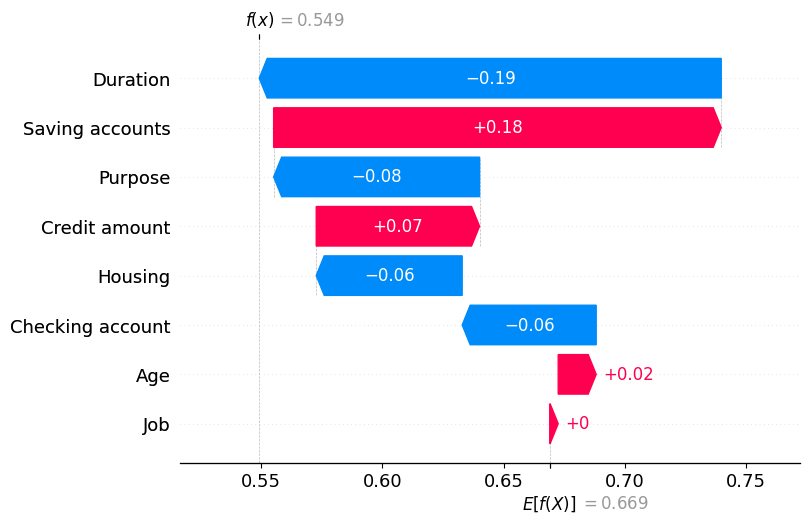

Predicted probability (class 1): 0.5741  →  class 1


In [34]:
feature_idx_num = feature_names_out.index('Credit amount')
plot_shap_waterfall_nn(explainer, sample_df.to_numpy(), feature_names_out, X_test_t)

#### Sampling

In [38]:
res = minimal_flip(model, X_test_df, idx, feature='Duration', max_steps=100, step_fraction=0.01, direction=-1)
res

{'original_class': 1,
 'flipped_class': 1,
 'feature': 'Duration',
 'total_change': 0,
 'steps': 0,
 'sample_cf':          Age  Credit amount  Duration  Checking account  Saving accounts  \
 71  0.229868       1.262123 -2.290968          1.074861        -1.235378   
 
      Housing   Purpose       Job  
 71 -2.443298  1.977903  0.146418  }

In [39]:
res["sample_cf"]

,Age,Credit amount,Duration,Checking account,Saving accounts,Housing,Purpose,Job
71,0.229868,1.262123,-2.290968,1.074861,-1.235378,-2.443298,1.977903,0.146418


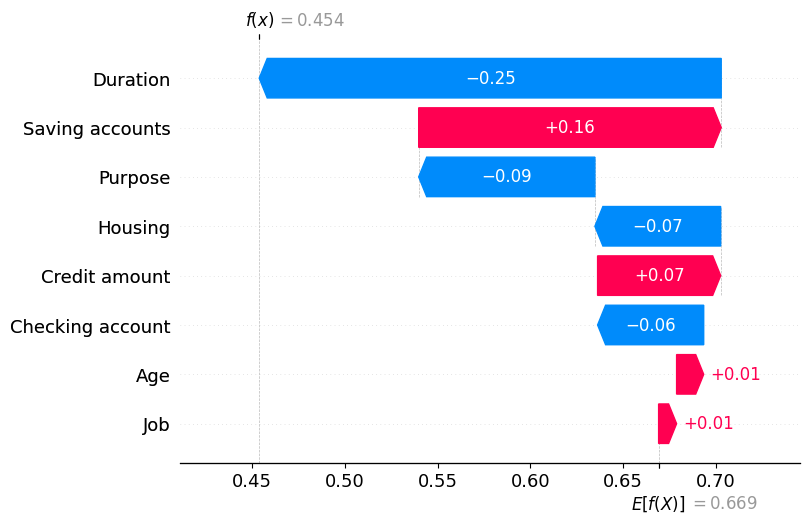

Predicted probability (class 1): 0.4992  →  class 0


In [37]:
plot_shap_waterfall_nn(explainer, res["sample_cf"].values, feature_names_out, X_test_t)

The required minimal change was much smaller than I anticipated **0.73 vs 3.2**, because the parameter values are highly dependent on each other and changing values for one criterion, affects the evaluation of other criterions in a way that is difficult to predict.

### Sample 131

#### Analytical

In [ ]:
idx = 131
sample_proc = X_test_proc[[idx]]
sample_df = X_test_df.iloc[[idx]].copy()

In [ ]:
plot_shap_waterfall_nn(explainer, sample_proc, feature_names_out, X_test_t)

In [ ]:
display(sample_df)

#### Sampling

In [ ]:
# ── Sampling: minimal_flip_nn ──────────────────────────────────────────────
res = minimal_flip(model, X_test_df, idx, feature="Checking account",
                      max_steps=100, step_fraction=0.01, direction=-1)
print(res)

plot_shap_waterfall_nn(explainer, res["sample_cf"].values, feature_names_out, X_test_t)